# Racial Disparities in North Carolina Traffic Stop Arrests
**SDS 357 — Midterm Analysis**

Analysis of 4M+ traffic stops across six North Carolina cities (2000–2015) from the Stanford Open Policing Project (SOPP), supplemented with FBI Uniform Crime Report data.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import (roc_auc_score, average_precision_score,
                             roc_curve, precision_recall_curve,
                             confusion_matrix, f1_score, classification_report)
from sklearn.preprocessing import LabelEncoder
from sklearn.inspection import permutation_importance

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook", font_scale=1.05)

PALETTE_RACE = {"black": "#4C72B0", "white": "#DD8452",
                "hispanic": "#55A868", "asian/pacific islander": "#C44E52"}
RACE_ORDER = ["black", "white", "hispanic", "asian/pacific islander"]
CITY_ORDER = ["Charlotte", "Raleigh", "Greensboro", "Fayetteville", "Winston-Salem", "Durham"]
SEED = 42

## Data Loading & Preparation

In [2]:
df = pd.read_parquet("data/nc_traffic_stops_cleaned.parquet")
df = df[df["subject_race"].isin(RACE_ORDER)].copy()
df = df[~df["outcome_missing"]].copy()
df = df[df["hour"].notna() & df["subject_age"].notna()].copy()
df["hour"] = df["hour"].astype(int)
df["subject_age"] = df["subject_age"].astype(float)
df = df.reset_index(drop=True)

# Merge FBI crime rates (violent + property per 1k) by city-year
fbi = pd.read_csv("data/nc_fbi_crime_data_clean.csv", index_col=0)
fbi["violent_crime_rate"] = fbi["Violent crime"] / fbi["Population"] * 1000
fbi["property_crime_rate"] = fbi["Property crime"] / fbi["Population"] * 1000
df = df.merge(fbi[["City", "Year", "violent_crime_rate", "property_crime_rate"]],
              left_on=["city", "year"], right_on=["City", "Year"], how="left")
df.drop(columns=["City", "Year"], inplace=True)
# Fill years outside FBI coverage with city-level averages
city_avg = fbi.groupby("City")[["violent_crime_rate", "property_crime_rate"]].mean()
for col in ["violent_crime_rate", "property_crime_rate"]:
    df[col] = df.apply(lambda r: city_avg.loc[r["city"], col]
                        if pd.isna(r[col]) else r[col], axis=1)

print(f"Dataset: {len(df):,} stops across {df['city'].nunique()} cities ({int(df['year'].min())}–{int(df['year'].max())})")
print(f"Arrest rate: {df['arrested'].mean()*100:.2f}%")
print(f"FBI crime rates merged: violent_crime_rate and property_crime_rate columns added")
df.head()

Dataset: 3,961,022 stops across 6 cities (2000–2015)
Arrest rate: 2.81%
FBI crime rates merged: violent_crime_rate and property_crime_rate columns added


,date,time,city,subject_race,subject_sex,subject_age,reason_for_stop,outcome,search_conducted,arrested,year,month,day_of_week,hour,outcome_missing,violent_crime_rate,property_crime_rate
0,2000-01-01,17:20:00,Charlotte,black,female,38.0,Safe Movement Violation,warning,False,0,2000,1,Saturday,17,False,7.461077,48.541918
1,2000-01-02,11:40:00,Charlotte,hispanic,male,33.0,Vehicle Regulatory Violation,citation,False,0,2000,1,Sunday,11,False,7.461077,48.541918
2,2000-01-02,02:41:00,Charlotte,white,male,23.0,Vehicle Equipment Violation,citation,False,0,2000,1,Sunday,2,False,7.461077,48.541918
3,2000-01-23,03:35:00,Charlotte,white,female,23.0,Vehicle Regulatory Violation,citation,False,0,2000,1,Sunday,3,False,7.461077,48.541918
4,2000-01-02,16:45:00,Charlotte,white,female,23.0,Safe Movement Violation,warning,False,0,2000,1,Sunday,16,False,7.461077,48.541918


## Exploratory Data Analysis

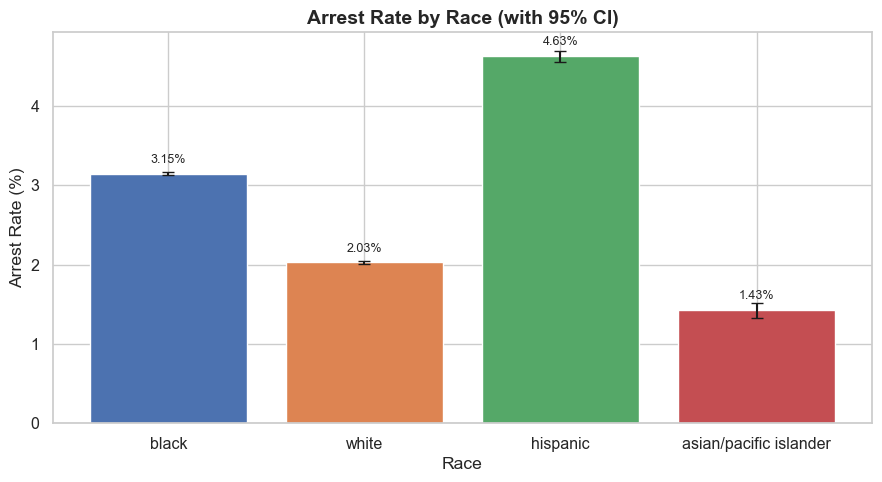

In [3]:
# Figure 1: Arrest Rate by Race (with 95% CI)
def arrest_rate_ci(group, z=1.96):
    n = len(group); p = group.mean()
    se = np.sqrt(p*(1-p)/n) if n > 0 else 0
    return pd.Series({"rate": p*100, "ci": z*se*100, "n": n})

arr_race = df.groupby("subject_race")["arrested"].apply(arrest_rate_ci).unstack()
arr_race = arr_race.reindex([r for r in RACE_ORDER if r in arr_race.index])

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(arr_race.index, arr_race["rate"], yerr=arr_race["ci"], capsize=4,
              color=[PALETTE_RACE[r] for r in arr_race.index], edgecolor="white")
ax.set_title("Arrest Rate by Race (with 95% CI)", fontsize=14, fontweight="bold")
ax.set_xlabel("Race"); ax.set_ylabel("Arrest Rate (%)")
for b, rate in zip(bars, arr_race["rate"]):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.1, f"{rate:.2f}%",
            ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()

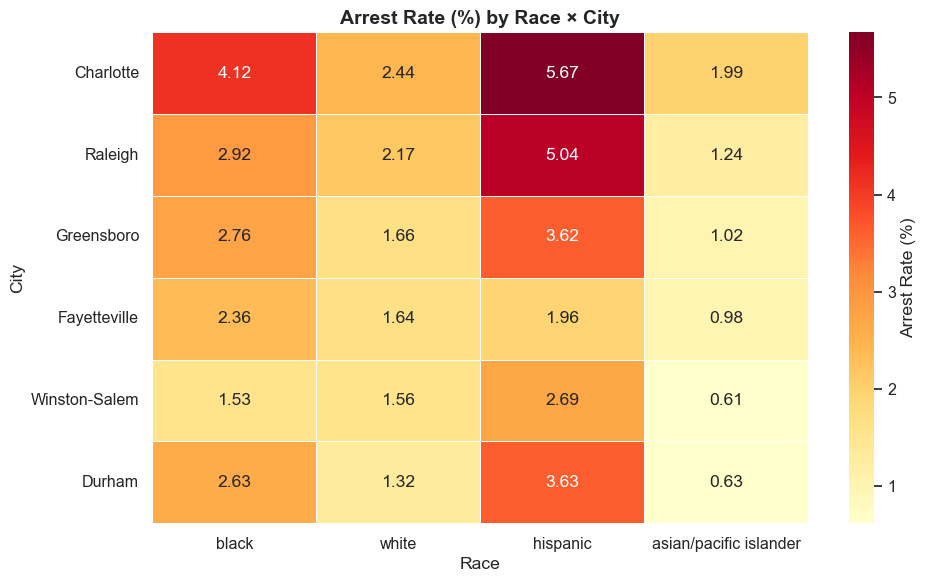

In [4]:
# Figure 2: Arrest Rate (%) by Race x City — Heatmap
arr_rc = df.groupby(["city", "subject_race"])["arrested"].mean().unstack() * 100
arr_rc = arr_rc.reindex(index=[c for c in CITY_ORDER if c in arr_rc.index],
                        columns=[r for r in RACE_ORDER if r in arr_rc.columns])

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(arr_rc, annot=True, fmt=".2f", cmap="YlOrRd", linewidths=0.5, ax=ax,
            cbar_kws={"label": "Arrest Rate (%)"})
ax.set_title("Arrest Rate (%) by Race × City", fontsize=14, fontweight="bold")
ax.set_xlabel("Race"); ax.set_ylabel("City")
plt.tight_layout()
plt.show()

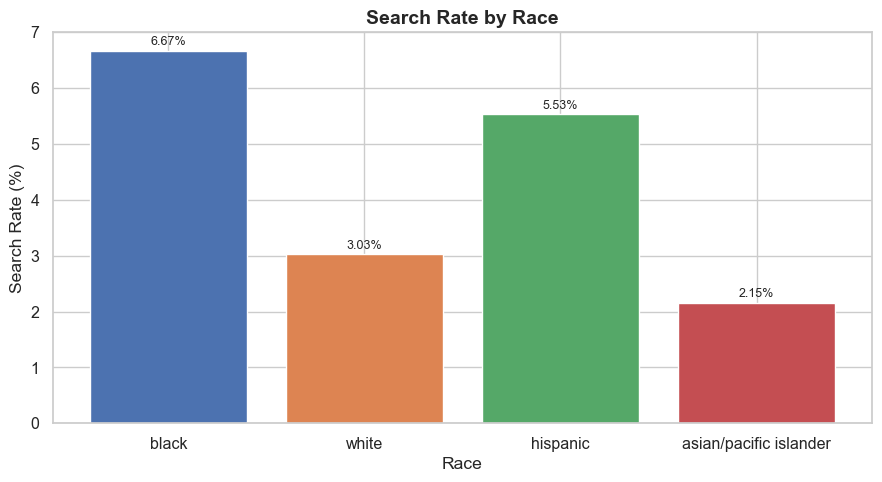

In [5]:
# Figure 3: Search Rate by Race
search_race = df.groupby("subject_race")["search_conducted"].mean() * 100
search_race = search_race.reindex([r for r in RACE_ORDER if r in search_race.index])

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(search_race.index, search_race.values,
              color=[PALETTE_RACE[r] for r in search_race.index], edgecolor="white")
ax.set_title("Search Rate by Race", fontsize=14, fontweight="bold")
ax.set_xlabel("Race"); ax.set_ylabel("Search Rate (%)")
for b, rate in zip(bars, search_race.values):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.05, f"{rate:.2f}%",
            ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()

## FBI Crime Data — Contextualizing Stop and Arrest Rates

In [6]:
# Load FBI Uniform Crime Report data for NC cities
fbi = pd.read_csv("data/nc_fbi_crime_data_clean.csv", index_col=0)
fbi["violent_crime_rate"] = fbi["Violent crime"] / fbi["Population"] * 1000
fbi["property_crime_rate"] = fbi["Property crime"] / fbi["Population"] * 1000
fbi = fbi.sort_values(["City", "Year"])
print(f"FBI data: {len(fbi)} city-year records, years {fbi['Year'].min()}–{fbi['Year'].max()}")
fbi[["City", "Year", "Population", "violent_crime_rate", "property_crime_rate"]].head(10)

FBI data: 52 city-year records, years 2006–2015


,City,Year,Population,violent_crime_rate,property_crime_rate
15,Charlotte,2006,699398,10.769262,69.897254
0,Charlotte,2007,733291,9.863751,69.929946
40,Charlotte,2008,758769,9.317724,61.855453
46,Charlotte,2009,777708,7.232792,49.546874
21,Charlotte,2010,797733,6.131124,43.499517
27,Charlotte,2011,789478,6.063500,40.543245
9,Charlotte,2012,808504,6.478632,40.305305
4,Charlotte,2013,837638,6.080192,36.494285
35,Charlotte,2014,856916,5.897894,35.668607
32,Charlotte,2015,877817,6.775900,37.678696


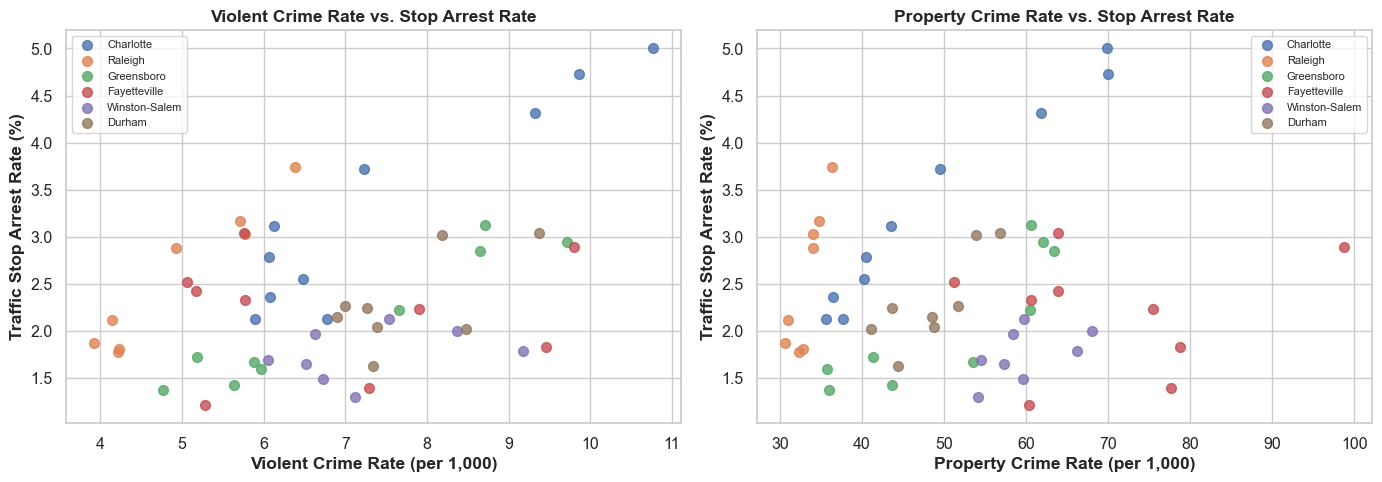

In [7]:
# Merge FBI crime rates with traffic stop arrest rates by city-year
stops_by_cy = df.groupby(["city", "year"]).agg(
    n_stops=("arrested", "size"),
    n_arrests=("arrested", "sum"),
    arrest_rate=("arrested", "mean")
).reset_index()
stops_by_cy["arrest_rate"] *= 100

merged = stops_by_cy.merge(fbi[["City", "Year", "violent_crime_rate", "property_crime_rate"]],
                           left_on=["city", "year"], right_on=["City", "Year"], how="inner")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, crime_col, label in zip(axes,
    ["violent_crime_rate", "property_crime_rate"],
    ["Violent Crime Rate (per 1,000)", "Property Crime Rate (per 1,000)"]):
    for city in CITY_ORDER:
        sub = merged[merged["city"] == city]
        ax.scatter(sub[crime_col], sub["arrest_rate"], label=city, s=50, alpha=0.8)
    ax.set_xlabel(label, fontweight="bold")
    ax.set_ylabel("Traffic Stop Arrest Rate (%)", fontweight="bold")
    ax.legend(fontsize=8)
axes[0].set_title("Violent Crime Rate vs. Stop Arrest Rate", fontweight="bold")
axes[1].set_title("Property Crime Rate vs. Stop Arrest Rate", fontweight="bold")
plt.tight_layout()
plt.show()

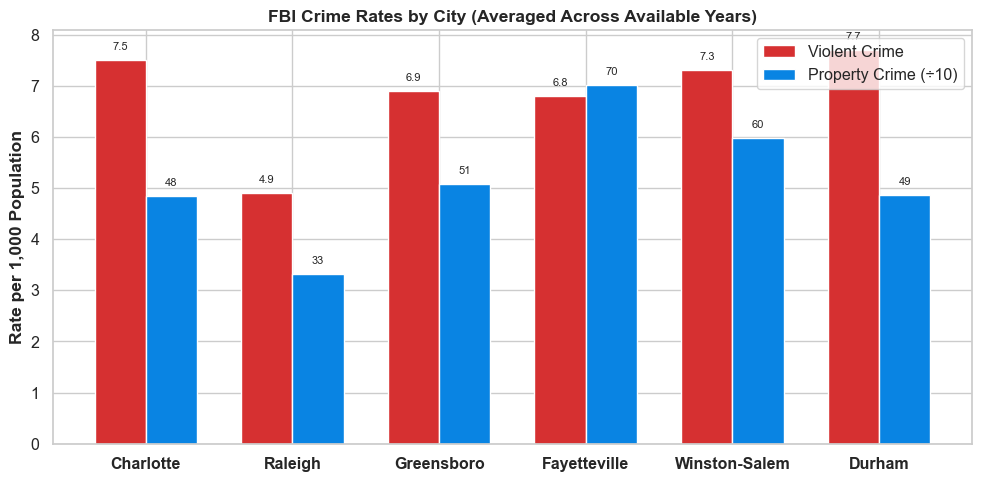

In [8]:
# FBI violent crime rate per capita by city (averaged across available years)
fbi_avg = fbi.groupby("City")[["violent_crime_rate", "property_crime_rate"]].mean().round(1)
fbi_avg = fbi_avg.reindex([c for c in CITY_ORDER if c in fbi_avg.index])

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(fbi_avg))
w = 0.35
ax.bar(x - w/2, fbi_avg["violent_crime_rate"], w, label="Violent Crime", color="#d63031")
ax.bar(x + w/2, fbi_avg["property_crime_rate"] / 10, w, label="Property Crime (÷10)", color="#0984e3")
ax.set_xticks(x)
ax.set_xticklabels(fbi_avg.index, fontweight="bold")
ax.set_ylabel("Rate per 1,000 Population", fontweight="bold")
ax.set_title("FBI Crime Rates by City (Averaged Across Available Years)", fontweight="bold")
ax.legend()
for i, (v, p) in enumerate(zip(fbi_avg["violent_crime_rate"], fbi_avg["property_crime_rate"])):
    ax.text(i - w/2, v + 0.2, f"{v:.1f}", ha="center", fontsize=8)
    ax.text(i + w/2, p/10 + 0.2, f"{p:.0f}", ha="center", fontsize=8)
plt.tight_layout()
plt.show()

## Inferential Analysis — Logistic Regression

P(Arrest | Driver Characteristics and Stop Conditions)

We use logistic regression to quantify the independent contribution of race, sex, and situational factors to the probability of arrest. All categorical variables are one-hot encoded with the first category dropped as a dummy variable. Library: `statsmodels`.

In [9]:
# Logistic Regression — full model with demographics + FBI crime rate
top_reasons = df["reason_for_stop"].value_counts().head(8).index.tolist()
dflog = df.copy()
dflog["reason_cat"] = dflog["reason_for_stop"].where(dflog["reason_for_stop"].isin(top_reasons), "Other")

X = pd.get_dummies(
    dflog[["subject_race", "subject_sex", "subject_age",
           "reason_cat", "city", "search_conducted", "hour", "year",
           "violent_crime_rate"]],
    columns=["subject_race", "subject_sex", "reason_cat", "city"],
    drop_first=True, dtype=float)
X["search_conducted"] = X["search_conducted"].astype(float)
X = sm.add_constant(X)
y = dflog["arrested"]
mask = X.notna().all(axis=1) & y.notna()
X, y = X[mask], y[mask]

model = sm.Logit(y, X).fit(disp=0, maxiter=200)
print(f"Pseudo R²: {model.prsquared:.4f}")
print(f"Observations: {int(model.nobs):,}")

res = pd.DataFrame({
    "coef": model.params, "std_err": model.bse, "z": model.tvalues,
    "p_value": model.pvalues, "odds_ratio": np.exp(model.params),
    "or_ci_lower": np.exp(model.conf_int()[0]),
    "or_ci_upper": np.exp(model.conf_int()[1])
})
res[res["p_value"] < 0.05][["odds_ratio", "or_ci_lower", "or_ci_upper", "p_value"]].round(4)

Pseudo R²: 0.4563
Observations: 3,961,022


,odds_ratio,or_ci_lower,or_ci_upper,p_value
const,1.294092e+24,1.569444e+22,1.067050e+26,0.0
search_conducted,6.956530e+01,6.838050e+01,7.077070e+01,0.0
hour,9.746000e-01,9.737000e-01,9.756000e-01,0.0
year,9.708000e-01,9.687000e-01,9.729000e-01,0.0
subject_race_black,1.327000e+00,1.223700e+00,1.439000e+00,0.0
subject_race_hispanic,1.970800e+00,1.813800e+00,2.141500e+00,0.0
subject_race_white,1.234900e+00,1.138200e+00,1.339800e+00,0.0
subject_sex_male,1.305500e+00,1.281100e+00,1.330300e+00,0.0
reason_cat_Other,2.291940e+01,2.204850e+01,2.382470e+01,0.0
reason_cat_Other Motor Vehicle Violation,7.205000e-01,6.964000e-01,7.455000e-01,0.0


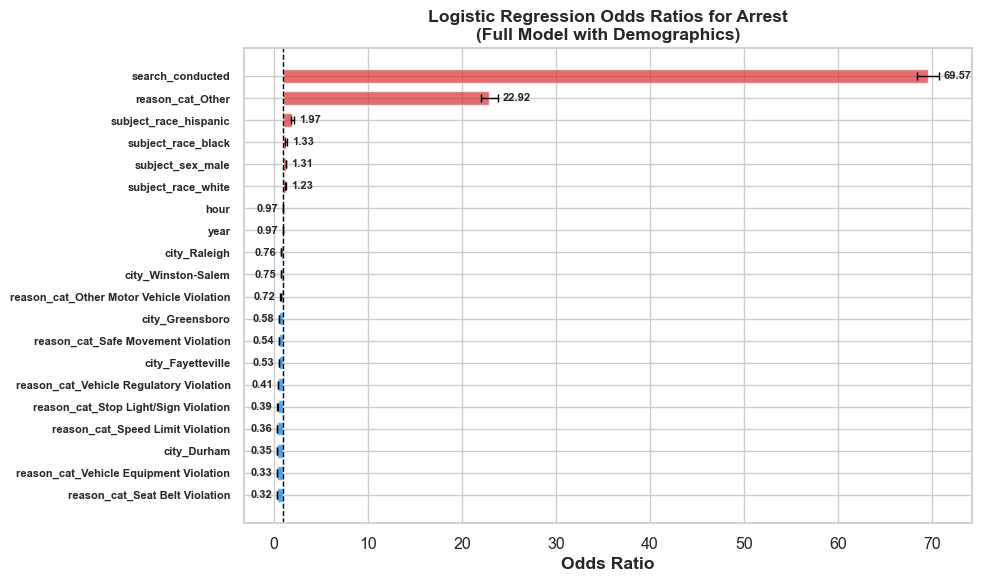

In [10]:
# Figure 4: Odds Ratios — significant features only
plot_df = res.drop(index=["const"], errors="ignore").copy()
plot_df = plot_df[plot_df["p_value"] < 0.05].sort_values("odds_ratio")

fig, ax = plt.subplots(figsize=(10, 6))
colors = ["#d63031" if v > 1 else "#0984e3" for v in plot_df["odds_ratio"]]
ax.barh(range(len(plot_df)), plot_df["odds_ratio"] - 1, left=1,
        color=colors, alpha=0.7, height=0.6)
ax.errorbar(plot_df["odds_ratio"], range(len(plot_df)),
            xerr=[plot_df["odds_ratio"] - plot_df["or_ci_lower"],
                  plot_df["or_ci_upper"] - plot_df["odds_ratio"]],
            fmt="none", ecolor="black", capsize=3, linewidth=1)
for i, (idx, row) in enumerate(plot_df.iterrows()):
    orv = row["odds_ratio"]
    offset = row["or_ci_upper"] + 0.5 if orv >= 1 else row["or_ci_lower"] - 0.5
    ha = "left" if orv >= 1 else "right"
    ax.text(offset, i, f"{orv:.2f}", va="center", ha=ha, fontsize=8, fontweight="bold")
ax.axvline(1, color="black", ls="--", lw=1)
ax.set_yticks(range(len(plot_df)))
ax.set_yticklabels(plot_df.index, fontsize=8, fontweight="bold")
ax.set_xlabel("Odds Ratio", fontweight="bold")
ax.set_title("Logistic Regression Odds Ratios for Arrest\n(Full Model with Demographics)", fontweight="bold")
plt.tight_layout()
plt.show()

## Race-Blind Predictive Model

Gradient-boosted classifier trained **without Race or Sex** to predict arrest based solely on situational context (stop reason, location, search status, time, age). We use `class_weight="balanced"` to address the 97:3 class imbalance, and select the optimal classification threshold by maximizing the F1 score on the test set.

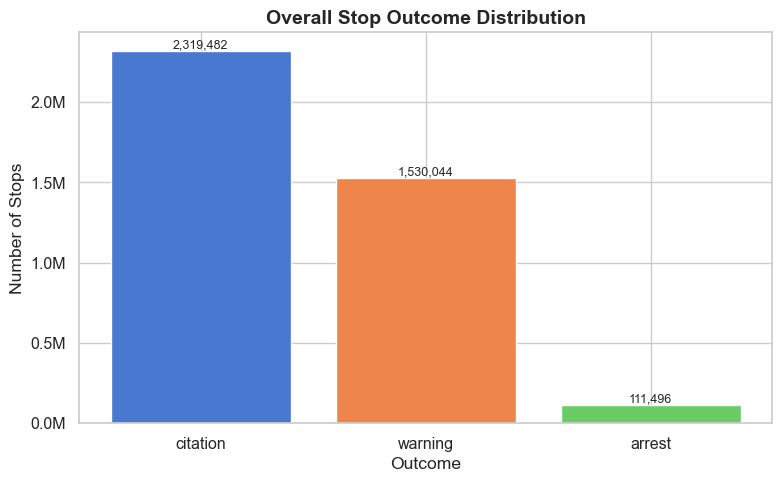

In [11]:
# Figure 5: Class imbalance — Overall Stop Outcome Distribution
outcome_counts = df[df["outcome"] != "nan"]["outcome"].value_counts()
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(outcome_counts.index, outcome_counts.values,
              color=sns.color_palette("muted", len(outcome_counts)))
ax.set_title("Overall Stop Outcome Distribution", fontsize=14, fontweight="bold")
ax.set_xlabel("Outcome"); ax.set_ylabel("Number of Stops")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))
for b in bars:
    ax.text(b.get_x()+b.get_width()/2, b.get_height(), f"{b.get_height():,.0f}",
            ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()

In [12]:
# Build race-blind model — 80/20 train-test split (includes FBI crime rate)
dfm = df.copy()
dfm["reason_cat"] = dfm["reason_for_stop"].where(
    dfm["reason_for_stop"].isin(top_reasons), "Other")

le_r = LabelEncoder(); le_c = LabelEncoder(); le_d = LabelEncoder()
dfm["reason_enc"] = le_r.fit_transform(dfm["reason_cat"])
dfm["city_enc"] = le_c.fit_transform(dfm["city"])
dfm["dow_enc"] = le_d.fit_transform(dfm["day_of_week"])

feat_cols = ["subject_age", "reason_enc", "city_enc",
             "search_conducted", "hour", "year", "month", "dow_enc",
             "violent_crime_rate"]
feat_names = ["Age", "Stop Reason", "City", "Search Conducted",
              "Hour", "Year", "Month", "Day of Week",
              "Violent Crime Rate (FBI)"]

Xm = dfm[feat_cols].copy()
Xm["search_conducted"] = Xm["search_conducted"].astype(int)
ym = dfm["arrested"]

X_tr, X_te, y_tr, y_te = train_test_split(Xm, ym, test_size=0.2,
                                           random_state=SEED, stratify=ym)

clf = HistGradientBoostingClassifier(max_iter=300, max_depth=6, learning_rate=0.1,
                                     min_samples_leaf=100, random_state=SEED,
                                     class_weight="balanced")
clf.fit(X_tr, y_tr)
prob_te = clf.predict_proba(X_te)[:, 1]
print("Model trained (with FBI violent crime rate feature).")

Model trained (with FBI violent crime rate feature).


## Performance Metrics

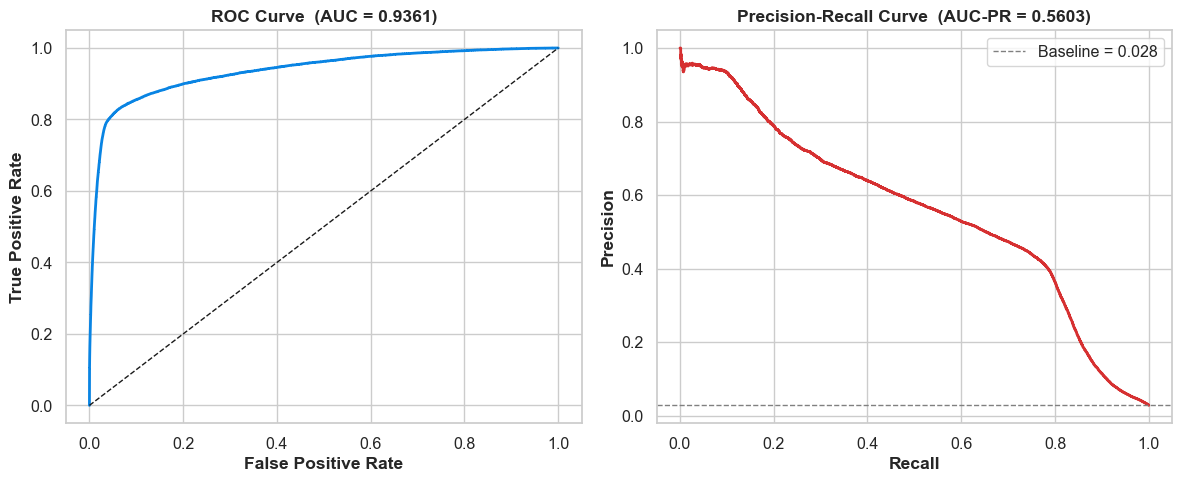

In [13]:
# Figure 6: ROC Curve + Precision-Recall Curve
auc_roc = roc_auc_score(y_te, prob_te)
auc_pr = average_precision_score(y_te, prob_te)
fpr, tpr, _ = roc_curve(y_te, prob_te)
prec, rec, _ = precision_recall_curve(y_te, prob_te)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
ax1.plot(fpr, tpr, color="#0984e3", lw=2)
ax1.plot([0, 1], [0, 1], "k--", lw=1)
ax1.set_xlabel("False Positive Rate", fontweight="bold")
ax1.set_ylabel("True Positive Rate", fontweight="bold")
ax1.set_title(f"ROC Curve  (AUC = {auc_roc:.4f})", fontweight="bold")

ax2.plot(rec, prec, color="#d63031", lw=2)
baseline = y_te.mean()
ax2.axhline(baseline, color="gray", ls="--", lw=1, label=f"Baseline = {baseline:.3f}")
ax2.set_xlabel("Recall", fontweight="bold")
ax2.set_ylabel("Precision", fontweight="bold")
ax2.set_title(f"Precision-Recall Curve  (AUC-PR = {auc_pr:.4f})", fontweight="bold")
ax2.legend()
plt.tight_layout()
plt.show()

In [14]:
# Performance summary + Confusion Matrix at optimal F1 threshold
thresholds = np.arange(0.02, 0.95, 0.005)
f1s = [f1_score(y_te, (prob_te >= t).astype(int)) for t in thresholds]
best_t = thresholds[np.argmax(f1s)]
best_f1 = max(f1s)
y_pred = (prob_te >= best_t).astype(int)
cm = confusion_matrix(y_te, y_pred)

print(f"Baseline (arrest rate):  {baseline:.4f}")
print(f"AUC-ROC:                 {auc_roc:.4f}")
print(f"AUC-PR:                  {auc_pr:.4f}")
print(f"Best F1 Score:           {best_f1:.4f}")
print(f"Optimal Threshold:       {best_t:.3f}")
print(f"\nConfusion Matrix (threshold = {best_t:.3f}):")
cm_df = pd.DataFrame(cm, index=["Actual No Arrest", "Actual Arrest"],
                         columns=["Predicted No Arrest", "Predicted Arrest"])
cm_df

Baseline (arrest rate):  0.0281
AUC-ROC:                 0.9361
AUC-PR:                  0.5603
Best F1 Score:           0.5667
Optimal Threshold:       0.940

Confusion Matrix (threshold = 0.940):


,Predicted No Arrest,Predicted Arrest
Actual No Arrest,756842,13064
Actual Arrest,8317,13982


## Feature Importance

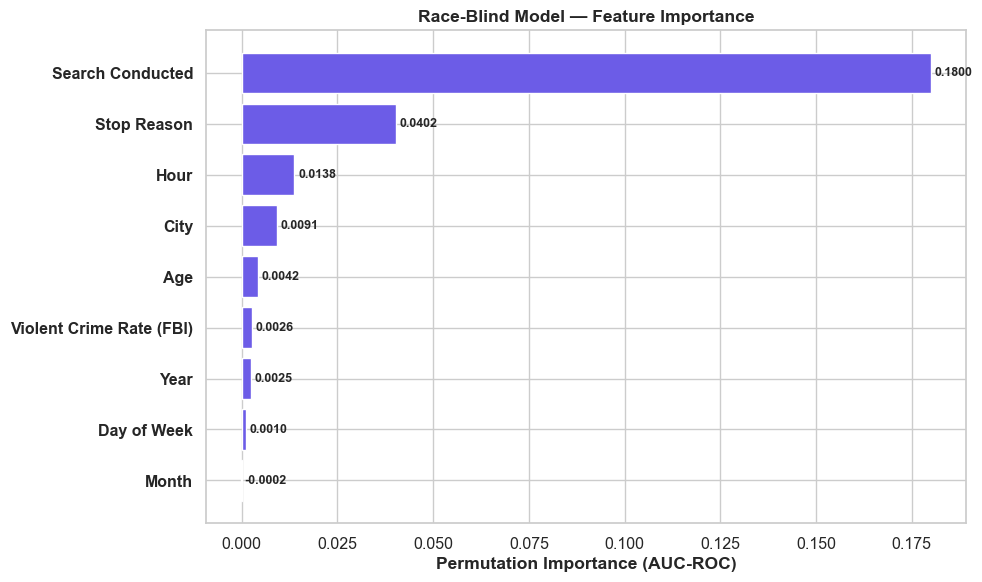

In [15]:
# Figure 7: Permutation Importance (race-blind model)
sample_idx = np.random.RandomState(SEED).choice(len(X_te), min(20_000, len(X_te)), replace=False)
pi = permutation_importance(clf, X_te.iloc[sample_idx], y_te.iloc[sample_idx],
                            n_repeats=5, random_state=SEED, scoring="roc_auc")
imp = pi.importances_mean
order = np.argsort(imp)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(range(len(imp)), imp[order], color="#6c5ce7")
for bar, idx in zip(bars, order):
    val = imp[idx]
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
            f"{val:.4f}", va="center", fontsize=9, fontweight="bold")
ax.set_yticks(range(len(imp)))
ax.set_yticklabels([feat_names[i] for i in order], fontweight="bold")
ax.set_xlabel("Permutation Importance (AUC-ROC)", fontweight="bold")
ax.set_title("Race-Blind Model — Feature Importance", fontweight="bold")
plt.tight_layout()
plt.show()